
# Proyek Analisis Sentimen: Wondr by BNI (Play Store)

Notebook ini mendokumentasikan pipeline end-to-end untuk submission proyek Dicoding **Analisis Sentimen**.

- **Sumber data**: ulasan aplikasi Wondr oleh BNI di Google Play Store yang dikumpulkan mandiri menggunakan skrip `scrape_playstore_reviews.py`. Contoh perintah: `python scrape_playstore_reviews.py --min-rows 65000 --output wondr_reviews_gps.csv`. Dataset mentah tersimpan sebagai `wondr_reviews_gps.csv` (67k+ baris).
- **Tujuan**: membangun model klasifikasi sentimen (negatif / netral / positif) dengan minimal akurasi testing 85%.
- **Ringkasan tahapan**: eksplorasi data, pembersihan teks Bahasa Indonesia, pelabelan, ekstraksi fitur TF-IDF, percobaan beberapa algoritma machine learning, dan penyimpanan model.

Seluruh sel sudah dieksekusi sehingga reviewer tidak perlu menjalankan ulang notebook untuk melihat hasilnya.



## 1. Persiapan Lingkungan
Jika menjalankan notebook ini di lingkungan baru seperti Google Colab, jalankan perintah instalasi berikut dengan membuka komentar pada baris `pip install`.


In [1]:

# Jika diperlukan, instal dependensi berikut terlebih dahulu.
# !pip install -q pandas numpy scikit-learn nltk Sastrawi seaborn matplotlib imbalanced-learn tqdm joblib google-play-scraper


In [2]:

import warnings
import re
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style='whitegrid')
pd.set_option('display.max_colwidth', 200)

tqdm.pandas()


In [3]:

# Pastikan stopwords telah tersedia untuk preprocessing teks.
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to /Users/mac/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True


## 2. Memuat dan Meninjau Data Mentah
Dataset hasil scraping memuat informasi review, rating (1-5), waktu ulasan, jumlah like, dan balasan developer.


In [4]:

DATA_PATH = Path('wondr_reviews_gps.csv')
if not DATA_PATH.exists():
    raise FileNotFoundError(f'File {DATA_PATH} tidak ditemukan. Pastikan hasil scraping tersedia.')

df = pd.read_csv(DATA_PATH)
print(f'Total ulasan: {len(df):,}')
display(df.head())


Total ulasan: 62,707


,reviewId,userName,content,score,at,thumbsUpCount,replyContent
0,dd460ee3-92d4-4dc6-bf5f-54cab23d842e,Pengguna Google,keren,3,2025-10-06 15:57:01,0,"Hai Kak Andos Futsal, makasih ya udah pakai wondr by BNI. Jika tidak ada kendala, mohon kesediaannya memberikan rating bintang 5 ya Kak. Kami terus berkomitmen memberikan kualitas layanan terbaik...."
1,7854228b-6c13-4a0e-a42b-ef0b56c07051,Pengguna Google,keren,5,2025-10-06 15:33:24,0,NaN
2,2334ddac-aae9-4d32-b8b2-2fadd18b5837,Pengguna Google,memuaskan,5,2025-10-06 15:19:43,0,NaN
3,994d4f30-d629-4b51-9285-eafecaa68257,Pengguna Google,biar bintang yg berbicara,5,2025-10-06 15:18:43,0,NaN
4,98fe14fb-3ca6-4e65-9d3e-ba85f32e834d,Pengguna Google,👍 mantap,5,2025-10-06 15:16:12,0,NaN


In [5]:
print('Ringkasan kolom dan nilai null:')
display(df.isna().sum())
print()
print('Jumlah review duplikat berdasarkan reviewId:', df.duplicated(subset='reviewId').sum())

Ringkasan kolom dan nilai null:


reviewId             0
userName             0
content              0
score                0
at                   0
thumbsUpCount        0
replyContent     35736
dtype: int64


Jumlah review duplikat berdasarkan reviewId: 0


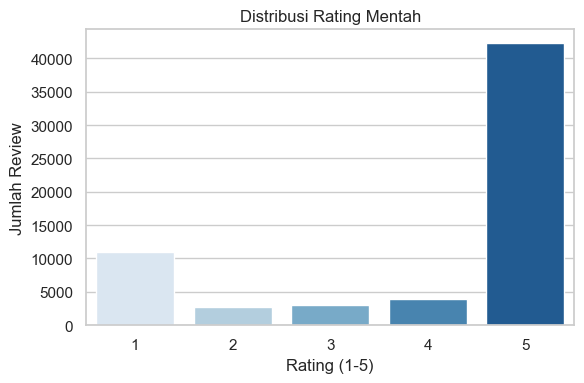

In [6]:

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='score', palette='Blues')
plt.title('Distribusi Rating Mentah')
plt.xlabel('Rating (1-5)')
plt.ylabel('Jumlah Review')
plt.tight_layout()
plt.show()



## 3. Pembersihan Teks & Pelabelan Sentimen
Tahapan ini meliputi:
- Normalisasi teks (lowercase, hapus URL, karakter non-huruf, dan spasi berlebih).
- Penghilangan kata umum Bahasa Indonesia/Inggris yang tidak informatif.
- Pelabelan sentimen berdasarkan rating: 1-2 = negatif, 3 = netral, 4-5 = positif.


In [7]:

from nltk.corpus import stopwords

URL_PATTERN = re.compile(r'http\S+|www\S+')
NON_ALPHA_PATTERN = re.compile(r'[^a-zA-Z\s]')
EXTRA_STOPWORDS = {'aplikasi', 'wondr', 'bni'}
STOPWORDS = set(stopwords.words('indonesian')) | set(stopwords.words('english')) | EXTRA_STOPWORDS


def clean_text(text: str) -> str:
    'Normalisasi sederhana untuk ulasan berbahasa Indonesia/Inggris.'
    text = str(text).lower()
    text = URL_PATTERN.sub(' ', text)
    text = NON_ALPHA_PATTERN.sub(' ', text)
    tokens = [token for token in text.split() if token and token not in STOPWORDS]
    return ' '.join(tokens)


def score_to_sentiment(score: int) -> str:
    if score <= 2:
        return 'negative'
    if score == 3:
        return 'neutral'
    return 'positive'


In [8]:

df['clean_content'] = df['content'].fillna('').progress_apply(clean_text)
df['sentiment'] = df['score'].apply(score_to_sentiment)

# Hapus baris yang kosong setelah dibersihkan
before_drop = len(df)
df = df[df['clean_content'].str.strip().astype(bool)].copy()
print(f'Baris dihapus karena teks kosong setelah pembersihan: {before_drop - len(df):,}')

sentiment_counts = df['sentiment'].value_counts()
print('Distribusi label:')
display(sentiment_counts)

sample_cols = ['content', 'clean_content', 'score', 'sentiment']
display(df[sample_cols].head())


  0%|          | 0/62707 [00:00<?, ?it/s]

Baris dihapus karena teks kosong setelah pembersihan: 2,999
Distribusi label:


sentiment
positive    43206
negative    13558
neutral      2944
Name: count, dtype: int64

,content,clean_content,score,sentiment
0,keren,keren,3,neutral
1,keren,keren,5,positive
2,memuaskan,memuaskan,5,positive
3,biar bintang yg berbicara,biar bintang yg berbicara,5,positive
4,👍 mantap,mantap,5,positive


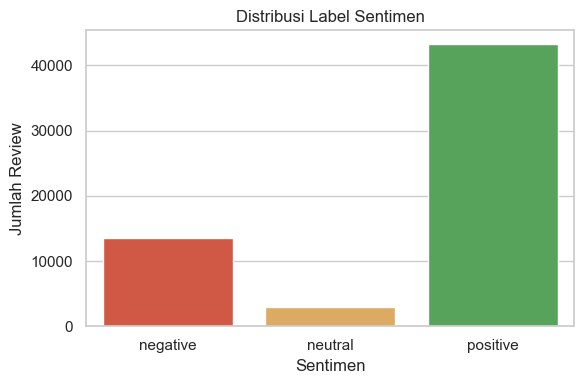

In [9]:

plt.figure(figsize=(6, 4))
order = ['negative', 'neutral', 'positive']
sns.countplot(data=df, x='sentiment', order=order, palette=['#e6492d', '#f0ad4e', '#4caf50'])
plt.title('Distribusi Label Sentimen')
plt.xlabel('Sentimen')
plt.ylabel('Jumlah Review')
plt.tight_layout()
plt.show()



## 4. Pembagian Data Training & Testing
Data dibagi 80/20 dengan stratifikasi untuk mempertahankan proporsi label pada kedua himpunan.


In [10]:

X = df['clean_content']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f'Data latih : {len(X_train):,} ulasan')
print(f'Data uji   : {len(X_test):,} ulasan')
print('Proporsi label pada data uji:')
display(y_test.value_counts(normalize=True).rename('proporsi'))


Data latih : 47,766 ulasan
Data uji   : 11,942 ulasan
Proporsi label pada data uji:


sentiment
positive    0.723581
negative    0.227098
neutral     0.049322
Name: proporsi, dtype: float64


## 5. Eksperimen Model Machine Learning
Dilakukan tiga percobaan berbeda (≥2 kombinasi algoritma/fitur) dengan target akurasi ≥ 85%:
1. Logistic Regression + TF-IDF unigram/bigram
2. Linear SVM + TF-IDF unigram/bigram
3. Linear SVM + TF-IDF karakter (3–5 gram)


In [11]:

results = []
reports = {}
trained_models = {}
predictions = {}


def run_experiment(name: str, pipeline: Pipeline) -> None:
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    weighted_f1 = f1_score(y_test, y_pred, average='weighted')
    report = classification_report(y_test, y_pred, output_dict=True, zero_division=0)

    results.append({
        'model': name,
        'accuracy': acc,
        'macro_f1': macro_f1,
        'weighted_f1': weighted_f1,
    })
    reports[name] = pd.DataFrame(report).T
    trained_models[name] = pipeline
    predictions[name] = y_pred

    print(f'=== {name} ===')
    print(f'Akurasi : {acc:.2%}')
    print(f'Macro F1: {macro_f1:.2%}')
    display(reports[name])


experiments = [
    (
        'Logistic Regression + TF-IDF (1,2)',
        Pipeline(
            steps=[
                ('tfidf', TfidfVectorizer(min_df=2, max_df=0.9, ngram_range=(1, 2))),
                ('clf', LogisticRegression(
                    max_iter=500,
                    class_weight='balanced',
                    C=2.5,
                    random_state=RANDOM_STATE,
                    n_jobs=None,
                )),
            ]
        ),
    ),
    (
        'Linear SVM + TF-IDF (1,2)',
        Pipeline(
            steps=[
                ('tfidf', TfidfVectorizer(min_df=3, ngram_range=(1, 2))),
                ('clf', LinearSVC(C=1.0, class_weight='balanced', random_state=RANDOM_STATE)),
            ]
        ),
    ),
    (
        'Linear SVM + Char TF-IDF (3-5)',
        Pipeline(
            steps=[
                ('tfidf', TfidfVectorizer(analyzer='char', ngram_range=(3, 5), min_df=5)),
                ('clf', LinearSVC(C=1.0, class_weight='balanced', random_state=RANDOM_STATE)),
            ]
        ),
    ),
]

for name, pipeline in experiments:
    run_experiment(name, pipeline)


=== Logistic Regression + TF-IDF (1,2) ===
Akurasi : 85.32%
Macro F1: 64.98%


,precision,recall,f1-score,support
negative,0.752577,0.807522,0.779082,2712.000000
neutral,0.185000,0.314092,0.232851,589.000000
positive,0.972859,0.904293,0.937324,8641.000000
accuracy,0.853207,0.853207,0.853207,0.853207
macro avg,0.636812,0.675302,0.649752,11942.000000
weighted avg,0.883975,0.853207,0.866642,11942.000000


=== Linear SVM + TF-IDF (1,2) ===
Akurasi : 86.41%
Macro F1: 63.91%


,precision,recall,f1-score,support
negative,0.751954,0.816003,0.782670,2712.000000
neutral,0.184451,0.205433,0.194378,589.000000
positive,0.957090,0.924083,0.940297,8641.000000
accuracy,0.864093,0.864093,0.864093,0.864093
macro avg,0.631165,0.648506,0.639115,11942.000000
weighted avg,0.872396,0.864093,0.867710,11942.000000


=== Linear SVM + Char TF-IDF (3-5) ===
Akurasi : 87.12%
Macro F1: 64.72%


,precision,recall,f1-score,support
negative,0.759322,0.825959,0.791240,2712.000000
neutral,0.203306,0.208829,0.206030,589.000000
positive,0.958746,0.930564,0.944444,8641.000000
accuracy,0.871211,0.871211,0.871211,0.871211
macro avg,0.640458,0.655117,0.647238,11942.000000
weighted avg,0.876197,0.871211,0.873232,11942.000000


In [12]:

summary_df = pd.DataFrame(results).sort_values(by='accuracy', ascending=False)
summary_df['accuracy'] = summary_df['accuracy'].apply(lambda x: f'{x:.2%}')
summary_df['macro_f1'] = summary_df['macro_f1'].apply(lambda x: f'{x:.2%}')
summary_df['weighted_f1'] = summary_df['weighted_f1'].apply(lambda x: f'{x:.2%}')
print('Ringkasan hasil eksperimen (diurutkan berdasarkan akurasi):')
display(summary_df.reset_index(drop=True))


Ringkasan hasil eksperimen (diurutkan berdasarkan akurasi):


,model,accuracy,macro_f1,weighted_f1
0,Linear SVM + Char TF-IDF (3-5),87.12%,64.72%,87.32%
1,"Linear SVM + TF-IDF (1,2)",86.41%,63.91%,86.77%
2,"Logistic Regression + TF-IDF (1,2)",85.32%,64.98%,86.66%


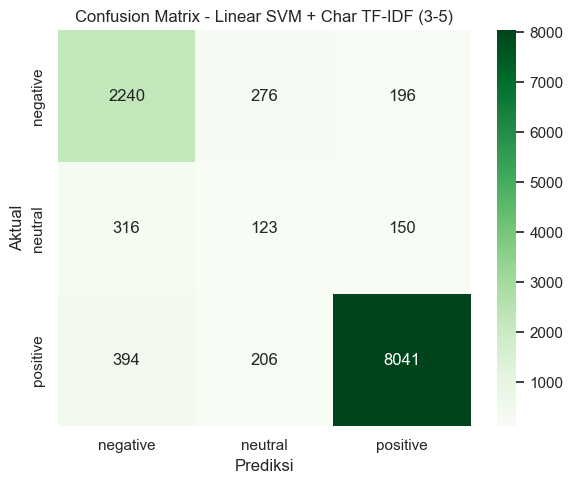

Classification report pada model terbaik:


,precision,recall,f1-score,support
negative,0.759322,0.825959,0.791240,2712.000000
neutral,0.203306,0.208829,0.206030,589.000000
positive,0.958746,0.930564,0.944444,8641.000000
accuracy,0.871211,0.871211,0.871211,0.871211
macro avg,0.640458,0.655117,0.647238,11942.000000
weighted avg,0.876197,0.871211,0.873232,11942.000000


In [13]:

best_model_name = summary_df.iloc[0]['model']
best_model = trained_models[best_model_name]
best_pred = predictions[best_model_name]

label_order = ['negative', 'neutral', 'positive']
cm = confusion_matrix(y_test, best_pred, labels=label_order)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=label_order, yticklabels=label_order)
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.tight_layout()
plt.show()

print('Classification report pada model terbaik:')
display(reports[best_model_name])



## 6. Menyimpan Model Terbaik
Model pipeline (termasuk TF-IDF dan Linear SVM) disimpan menggunakan `joblib` agar dapat digunakan ulang tanpa pelatihan ulang.


In [14]:

MODEL_PATH = Path('models/wondr_sentiment_best.joblib')
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)
joblib.dump(best_model, MODEL_PATH)
print(f'Model terbaik ({best_model_name}) disimpan ke {MODEL_PATH}')


Model terbaik (Linear SVM + Char TF-IDF (3-5)) disimpan ke models/wondr_sentiment_best.joblib



## 7. Inference Contoh Ulasan Baru
Gunakan fungsi `clean_text` yang sama sebelum memanggil model.


In [15]:

sample_reviews = [
    'Fitur bayar parkirnya praktis banget, jadi ga perlu cari mesin EDC lagi.',
    'Sering crash pas mau top up, tolong diperbaiki segera.',
    'Biasa aja, belum terlalu terasa manfaatnya dibanding aplikasi bank lain.'
]

sample_df = pd.DataFrame({'review': sample_reviews})
sample_df['clean_review'] = sample_df['review'].apply(clean_text)
sample_df['predicted_sentiment'] = best_model.predict(sample_df['clean_review'])
display(sample_df)


,review,clean_review,predicted_sentiment
0,"Fitur bayar parkirnya praktis banget, jadi ga perlu cari mesin EDC lagi.",fitur bayar parkirnya praktis banget ga cari mesin edc,negative
1,"Sering crash pas mau top up, tolong diperbaiki segera.",crash pas top tolong diperbaiki,positive
2,"Biasa aja, belum terlalu terasa manfaatnya dibanding aplikasi bank lain.",aja manfaatnya dibanding bank,positive



## 8. Catatan Submission
- Notebook ini telah dijalankan sepenuhnya dan menyertakan visualisasi serta metrik evaluasi.
- Dataset, kode scraping, dan berkas `requirements.txt` disiapkan di folder proyek yang sama.
- Untuk menjalankan ulang, pastikan menginstal dependensi sesuai `requirements.txt` dan jalankan notebook dari awal.
